## SPAD Position Optimization Sweep

This notebook connects to the running qudi instance and performs a **two-phase**
position optimization using `spad_optimize_logic`:

1. **Z sweep** — find the optimal focus by sweeping Z and tracking the 9 brightest
   pixels (one per emitter in the 3×3 array).  The scanner is then moved to the
   peak-Z position.
2. **XY sweep** — at the optimal Z, sweep XY and compute the integrated 9-emitter
   counts using a fixed 5×5-footprint mask (every-other-pixel spacing) anchored to
   the brightest pixel found during the Z sweep.

The feedback between phases ensures the XY sweep is performed at best focus.

**Prerequisites:**
- qudi is running with `spad_optimize_logic`, `spad_probe_logic`, and `camera_SPC3` activated
- The SPC3 camera live view is **stopped** (snap mode requires it)
- Optimizer settings (scan range, resolution) are configured in `scanner_spad_gui`
- The scanner is positioned at the approximate centre of the region of interest

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)

# Access qudi modules (available in the kernel namespace)
opt      = spad_optimize_logic
spad     = spad_probe_logic
cam      = camera_SPC3
cam_logic = camera_logic

print(f'Scanner position : {dict(spad.scanner_target)}')
print(f'Optimizer running: {opt.optimizer_running}')

Scanner position : {'x': 8.96717e-05, 'y': 7.65618e-05, 'z': 0.0001082655}
Optimizer running: False


## Inspect / override optimizer settings

The sweep uses the optimizer settings that are already configured in `scanner_spad_gui`.
You can inspect them below and optionally override range or resolution before starting.

In [3]:
# Current optimizer settings (set via scanner_spad_gui)
print('Scan sequence :', opt.scan_sequence)
print('Scan range    :', {k: f'{v*1e6:.1f} µm' for k, v in opt.scan_range.items()})
print('Scan resolution:', opt.scan_resolution)
#print('Data channel  :', opt.data_channel)
#print('NFrames       :', cam._NFrames, ' (frames averaged per position)')
#print('NFrames       :', 1, ' (frames averaged per position)')

# --- Optional: override NFrames from notebook ---
# Use camera_logic.set_snap_frames() which runs in-process on the qudi side.
# Setting cam._NFrames directly via rpyc only changes the local proxy, not the remote object.
NFRAMES = 10   # frames to snap & average at each position
cam_logic.set_snap_frames(NFRAMES)

# --- Optional: override optimizer settings from notebook ---
# Uncomment and adjust as needed:
#
# opt.set_optimize_settings(
#     data_channel='APD1',
#     scan_sequence=(('x', 'y'), ('z',)),
#     scan_dimension=[2, 1],
#     range={'x': 10e-6, 'y': 10e-6, 'z': 5e-6},     # sweep range per axis (m)
#     resolution={'x': 20, 'y': 20, 'z': 15},          # points per axis
#     frequency={'x': 50, 'y': 50, 'z': 50},            # not used for SPAD sweep, kept for GUI compat
# )

Scan sequence : (('x',), ('y', 'z'))
Scan range    : {'x': '0.5 µm', 'y': '0.5 µm', 'z': '5.0 µm'}
Scan resolution: {'x': 10, 'y': 10, 'z': 100}


True

## Phase 1 — Z Focus Sweep

Override the scan sequence to Z-only, run the sweep, and find the optimal focus.

The optimizer will:
1. Set `trigger_mode='no_trigger'` on the SPC3
2. Step through the Z grid, snapping NFrames at each position
3. Restore trigger mode and return scanner to the starting position

In [7]:
# Set sequence to Z-only
opt.scan_sequence = (('z',),)
print('Scan sequence set to:', opt.scan_sequence)

# Start Z sweep
opt.start_optimize()

t0 = time.time()
while opt.optimizer_running:
    time.sleep(0.5)
    elapsed = time.time() - t0
    print(f'\rZ sweep running... {elapsed:.0f}s', end='', flush=True)

elapsed = time.time() - t0
print(f'\nZ sweep complete in {elapsed:.1f}s')

Scan sequence set to: (('z',),)
Z sweep running... 71s
Z sweep complete in 71.0s


## Retrieve & analyse Z sweep

Find the optimal Z by plotting the sum of the 9 brightest pixels vs Z position.
The brightest pixel in the peak-Z frame identifies the centre of the 3×3 emitter
array and will be used as the mask anchor for the XY sweep.

In [8]:
# Retrieve Z sweep data
z_data_remote = opt.spad_scan_data
z_step = {
    'axes':   tuple(z_data_remote[0]['axes']),
    'grids':  {k: np.array(v) * 1e6 for k, v in z_data_remote[0]['grids'].items()},
    'frames': np.array(z_data_remote[0]['frames']),
    'center': {k: v * 1e6 for k, v in z_data_remote[0]['center'].items()},
}

ax = z_step['axes'][0]
z_pos = z_step['grids'][ax]
frames_z = z_step['frames']
print(f'Z sweep: {z_pos[0]:.2f} – {z_pos[-1]:.2f} µm, {len(z_pos)} points, '
      f'frames shape {frames_z.shape}')

Z sweep: 106.55 – 111.55 µm, 100 points, frames shape (100, 32, 32)


### Z analysis & move to optimal focus

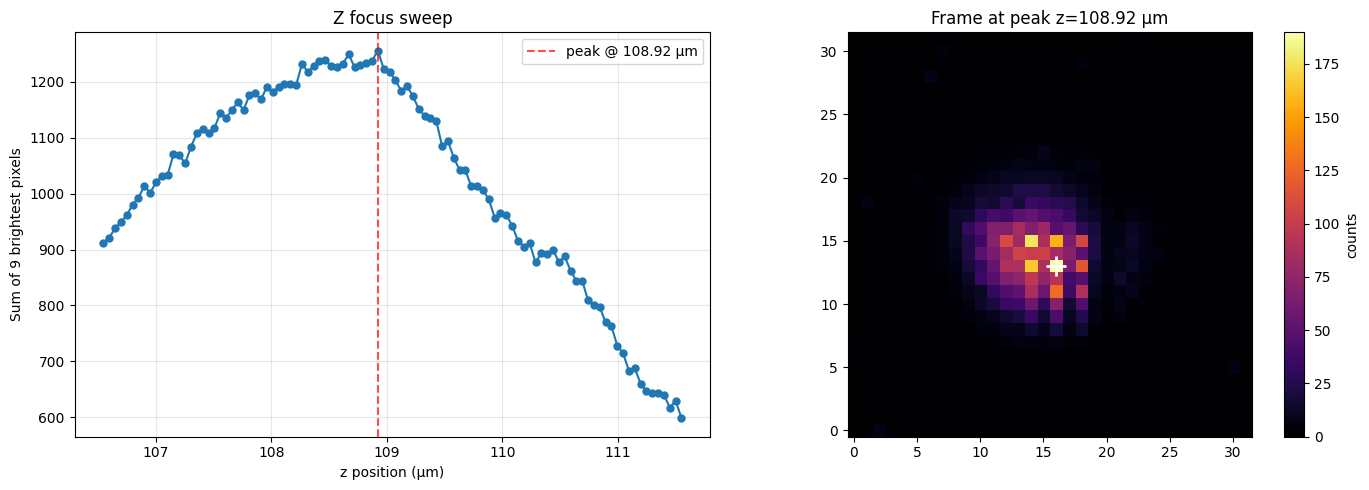

Peak z position : 108.92 µm  (top-9 sum = 1256 counts)
Centre was at     : 109.05 µm
Array centre pixel: row=13, col=16

Scanner moved to z=108.92 µm


In [9]:
N_EMITTERS = 9  # 3x3 emitter array — one pixel per emitter

def top_n_sum(frame, n=N_EMITTERS):
    """Sum the n brightest pixels in frame."""
    return np.sort(frame.ravel())[-n:].sum()

# Sum of brightest 9 pixels per z position
total_z = np.array([top_n_sum(f) for f in frames_z])

fig, axes_plt = plt.subplots(1, 2, figsize=(14, 5))

axes_plt[0].plot(z_pos, total_z, 'o-', ms=5, lw=1.5)
axes_plt[0].set_xlabel(f'{ax} position (µm)')
axes_plt[0].set_ylabel(f'Sum of {N_EMITTERS} brightest pixels')
axes_plt[0].set_title(f'{ax.upper()} focus sweep')
axes_plt[0].grid(True, alpha=0.3)

peak_z_idx = np.argmax(total_z)
optimal_z_um = z_pos[peak_z_idx]
axes_plt[0].axvline(optimal_z_um, color='r', ls='--', alpha=0.7,
                    label=f'peak @ {optimal_z_um:.2f} µm')
axes_plt[0].legend()

# Frame at peak Z — also find the brightest-pixel location for XY mask
peak_z_frame = frames_z[peak_z_idx]
bright_rc = np.unravel_index(peak_z_frame.argmax(), peak_z_frame.shape)

im = axes_plt[1].imshow(peak_z_frame, origin='lower', cmap='inferno')
axes_plt[1].set_title(f'Frame at peak {ax}={optimal_z_um:.2f} µm')
axes_plt[1].plot(bright_rc[1], bright_rc[0], 'w+', ms=14, mew=2)
fig.colorbar(im, ax=axes_plt[1], label='counts')

plt.tight_layout()
plt.show()

print(f'Peak {ax} position : {optimal_z_um:.2f} µm  (top-{N_EMITTERS} sum = {total_z[peak_z_idx]:.0f} counts)')
print(f'Centre was at     : {z_step["center"][ax]:.2f} µm')
print(f'Array centre pixel: row={bright_rc[0]}, col={bright_rc[1]}')

# ---- Move scanner to optimal Z for the XY sweep ----
optimal_z_m = optimal_z_um * 1e-6
spad.set_target_position({ax: optimal_z_m}, move_blocking=True)
print(f'\nScanner moved to {ax}={optimal_z_um:.2f} µm')

## Phase 2 — XY Sweep at Optimal Z

The scanner is now at the peak-Z position found above.
Override the scan sequence to XY-only and run the sweep.

The 9-emitter mask (every-other-pixel 3×3 grid within a 5×5 footprint) is anchored
to the brightest pixel identified from the peak-Z frame:

```
1 0 1 0 1
0 0 0 0 0
1 0 1 0 1
0 0 0 0 0
1 0 1 0 1
```

In [10]:
# Set sequence to XY-only
opt.scan_sequence = (('x', 'y'),)
print('Scan sequence set to:', opt.scan_sequence)

# Start XY sweep (centred on current scanner position, which is now at optimal Z)
opt.start_optimize()

t0 = time.time()
while opt.optimizer_running:
    time.sleep(0.5)
    elapsed = time.time() - t0
    print(f'\rXY sweep running... {elapsed:.0f}s', end='', flush=True)

elapsed = time.time() - t0
print(f'\nXY sweep complete in {elapsed:.1f}s')

Scan sequence set to: (('x', 'y'),)
XY sweep running... 71s
XY sweep complete in 70.5s


### Retrieve & analyse XY sweep

XY sweep: x 88.00–88.50 µm (10 pts), y 75.24–75.74 µm (10 pts)
  frames shape: (10, 10, 32, 32)


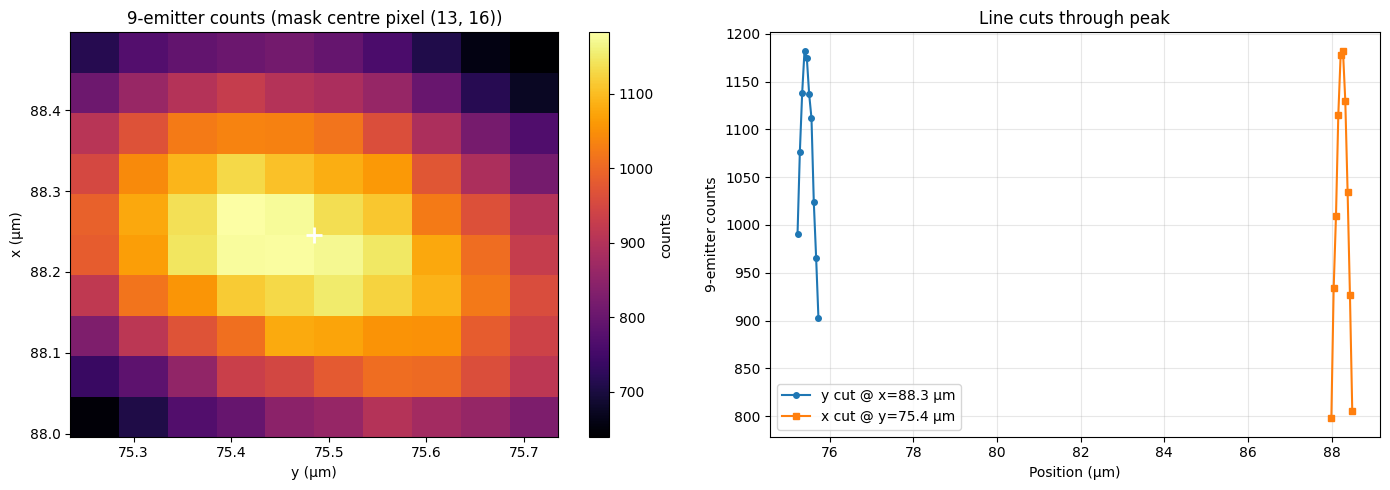

Peak XY: (x=88.27 µm, y=75.40 µm): 1182 counts (9-emitter sum)
Optimal Z was: 108.92 µm


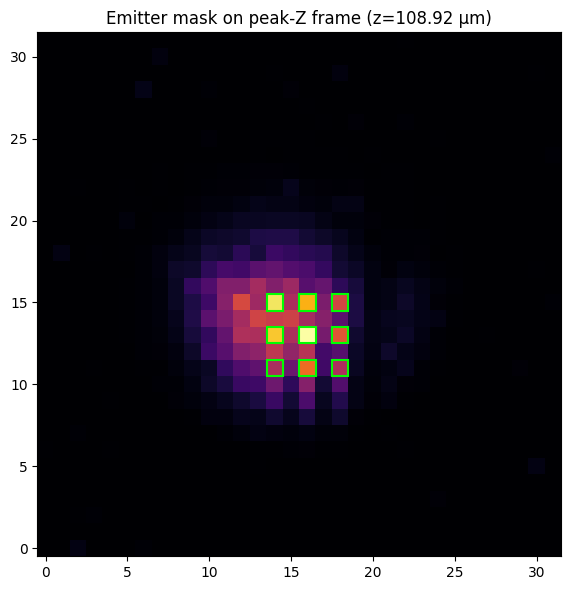

In [11]:
# Retrieve XY sweep data
xy_data_remote = opt.spad_scan_data
xy_step = {
    'axes':   tuple(xy_data_remote[0]['axes']),
    'grids':  {k: np.array(v) * 1e6 for k, v in xy_data_remote[0]['grids'].items()},
    'frames': np.array(xy_data_remote[0]['frames']),
    'center': {k: v * 1e6 for k, v in xy_data_remote[0]['center'].items()},
}

ax0, ax1 = xy_step['axes']
g0 = xy_step['grids'][ax0]
g1 = xy_step['grids'][ax1]
frames_xy = xy_step['frames']
print(f'XY sweep: {ax0} {g0[0]:.2f}–{g0[-1]:.2f} µm ({len(g0)} pts), '
      f'{ax1} {g1[0]:.2f}–{g1[-1]:.2f} µm ({len(g1)} pts)')
print(f'  frames shape: {frames_xy.shape}')

# 3×3 emitter mask: every other pixel → 5×5 footprint
# Offsets from centre pixel: -2, 0, +2 in both row and col
EMITTER_OFFSETS = [(-2, -2), (-2, 0), (-2, 2),
                   ( 0, -2), ( 0, 0), ( 0, 2),
                   ( 2, -2), ( 2, 0), ( 2, 2)]

def emitter_sum(frame, center_rc, offsets=EMITTER_OFFSETS):
    """Sum the 9 emitter pixels (every-other-pixel 3×3 grid) centred on center_rc."""
    r0, c0 = center_rc
    total = 0
    for dr, dc in offsets:
        r, c = r0 + dr, c0 + dc
        if 0 <= r < frame.shape[0] and 0 <= c < frame.shape[1]:
            total += frame[r, c]
    return total

# --- Integrated 9-emitter counts at each XY position ---
total_counts = np.zeros((len(g0), len(g1)))
for i in range(len(g0)):
    for j in range(len(g1)):
        total_counts[i, j] = emitter_sum(frames_xy[i, j], bright_rc)

fig, axes_plt = plt.subplots(1, 2, figsize=(14, 5))

# Image: 9-emitter integrated counts
extent = [g1[0], g1[-1], g0[0], g0[-1]]
im = axes_plt[0].imshow(total_counts, origin='lower', aspect='auto',
                        extent=extent, cmap='inferno')
axes_plt[0].set_xlabel(f'{ax1} (µm)')
axes_plt[0].set_ylabel(f'{ax0} (µm)')
axes_plt[0].set_title(f'9-emitter counts (mask centre pixel {bright_rc})')
fig.colorbar(im, ax=axes_plt[0], label='counts')

# Mark sweep centre
cx = xy_step['center'][ax1]
cy = xy_step['center'][ax0]
axes_plt[0].plot(cx, cy, 'w+', ms=12, mew=2)

# Line cuts through peak
peak_xy_idx = np.unravel_index(total_counts.argmax(), total_counts.shape)
axes_plt[1].plot(g1, total_counts[peak_xy_idx[0], :], 'o-', ms=4,
                 label=f'{ax1} cut @ {ax0}={g0[peak_xy_idx[0]]:.1f} µm')
axes_plt[1].plot(g0, total_counts[:, peak_xy_idx[1]], 's-', ms=4,
                 label=f'{ax0} cut @ {ax1}={g1[peak_xy_idx[1]]:.1f} µm')
axes_plt[1].set_xlabel('Position (µm)')
axes_plt[1].set_ylabel('9-emitter counts')
axes_plt[1].set_title('Line cuts through peak')
axes_plt[1].legend()
axes_plt[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Peak XY: ({ax0}={g0[peak_xy_idx[0]]:.2f} µm, {ax1}={g1[peak_xy_idx[1]]:.2f} µm): '
      f'{total_counts[peak_xy_idx]:.0f} counts (9-emitter sum)')
print(f'Optimal Z was: {optimal_z_um:.2f} µm')

# Show the emitter mask overlaid on the peak-Z frame
fig2, ax2 = plt.subplots(figsize=(6, 6))
ax2.imshow(peak_z_frame, origin='lower', cmap='inferno')
for dr, dc in EMITTER_OFFSETS:
    r, c = bright_rc[0] + dr, bright_rc[1] + dc
    rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                          linewidth=1.5, edgecolor='lime', facecolor='none')
    ax2.add_patch(rect)
ax2.set_title(f'Emitter mask on peak-Z frame (z={optimal_z_um:.2f} µm)')
plt.tight_layout()
plt.show()

## Move scanner to optimal XYZ position (optional)

After inspecting both sweep results, move the scanner to the combined optimal position.

In [12]:
# Move scanner to the optimal XYZ position

optimal_pos = {ax: optimal_z_m}   # Z from phase 1
optimal_pos[ax0] = g0[peak_xy_idx[0]] * 1e-6   # X from phase 2
optimal_pos[ax1] = g1[peak_xy_idx[1]] * 1e-6   # Y from phase 2

print(f'Moving to: { {k: f"{v*1e6:.2f} µm" for k, v in optimal_pos.items()} }')

# Update SPAD scanner
spad.set_target_position(optimal_pos, move_blocking=True)

# Update confocal scanner so both GUIs stay in sync
scanning_probe_logic.set_target_position(optimal_pos, move_blocking=True)

print('Done — both SPAD and confocal scanners updated.')

Moving to: {'z': '108.92 µm', 'x': '88.27 µm', 'y': '75.40 µm'}
Done — both SPAD and confocal scanners updated.
